In [1]:
import numpy
import scipy
import matplotlib.pyplot as plt
import matplotlib

metaRNG = numpy.random.default_rng (4711)

In [2]:
# popgen params
initF = 0.3
Ne = 2000
numGen = 500
selCoeff = 0.005

In [3]:
# simulate one trajectory
ts = numpy.arange(numGen+1)
ps = (-1) * numpy.ones(numGen+1)

ps[0] = initF

for t in ts[1:]:
    prevF = ps[t-1]
    newMu = prevF + selCoeff*prevF*(1-prevF)
    newSigmaSq = numpy.clip ((1/(2*Ne))*prevF*(1-prevF), a_min=0, a_max=1)
    ps[t] = metaRNG.normal (loc=newMu, scale=numpy.sqrt(newSigmaSq))

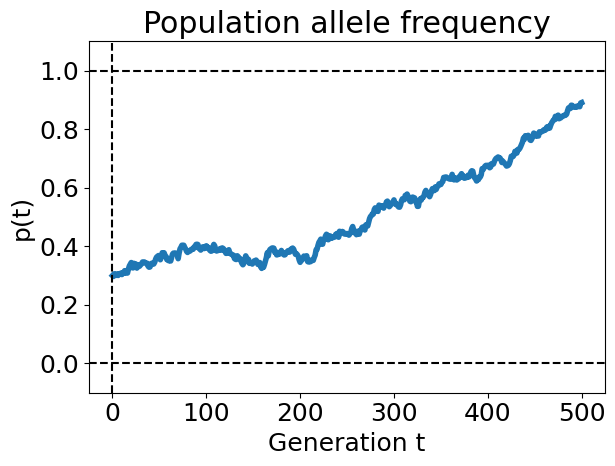

In [14]:
# text size
matplotlib.rcParams["font.size"] = 18

# make a nice plot
(fig, ax) = plt.subplots(figsize=(6.5,5))

# plotting stuff
ax.plot (ts, ps, lw=4)
ax.set_ylim (-0.1,1.1)
ax.axhline (1, color='black', ls='--')
ax.axhline (0, color='black', ls='--')
ax.axvline (0, color='black', ls='--')
ax.set_title ("Population allele frequency")
ax.set_ylabel ("p(t)")
ax.set_xlabel ("Generation t")

# save the nice plot
fig.tight_layout()
fig.savefig ("one_diffusion.pdf")